## Setup

In [31]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [32]:
from tapas_gmm.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm.policy.models.tpgmm
from tapas_gmm.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm.utils.logging import setup_logger  # noqa: F401
from tapas_gmm.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
#task = 'TurnOnLight'
serie = 'demos'
task = 'CloseDoorBack'
path = data_root / task / serie

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))


SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [34]:
gt_pose_config = {
    #'indeces': [1,2,3,4],
}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'front',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [35]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([69, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([69]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([69, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([69, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([69, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([69, 3, 256, 256]), device=cpu, dtype=to

In [36]:
tag="release"

tpgmm_config = TPGMMConfig(
    n_components=10,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,  # Use rotation aswell?
    add_gripper_action=True,
    heal_time_variance=False,
    reg_shrink=1e-2, # 1e-2 is 0.01
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,

    em_steps=50,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    use_bic=False, #Does prune segmentation
    drop_redundant_frames=True,
    gt_frames=[
        [0, 3],
        [0, 3],
        [0, 3],
    ]

)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    velocity_threshold=0.001,
    components_prop_to_len=True,
    min_end_distance=0,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [37]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-16 03:07:34.914 | INFO     |  Fitting AutoTPGMM
2025-08-16 03:07:34.914 | INFO     |  Segmenting trajectories


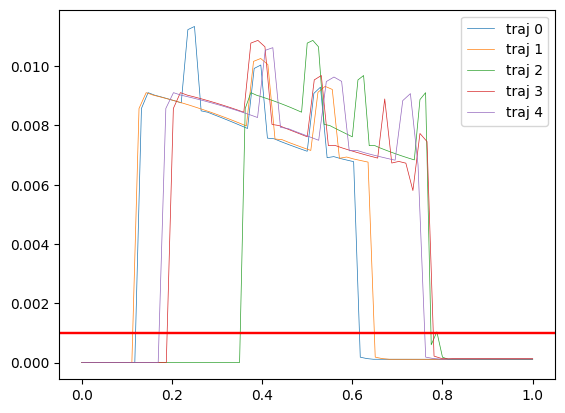

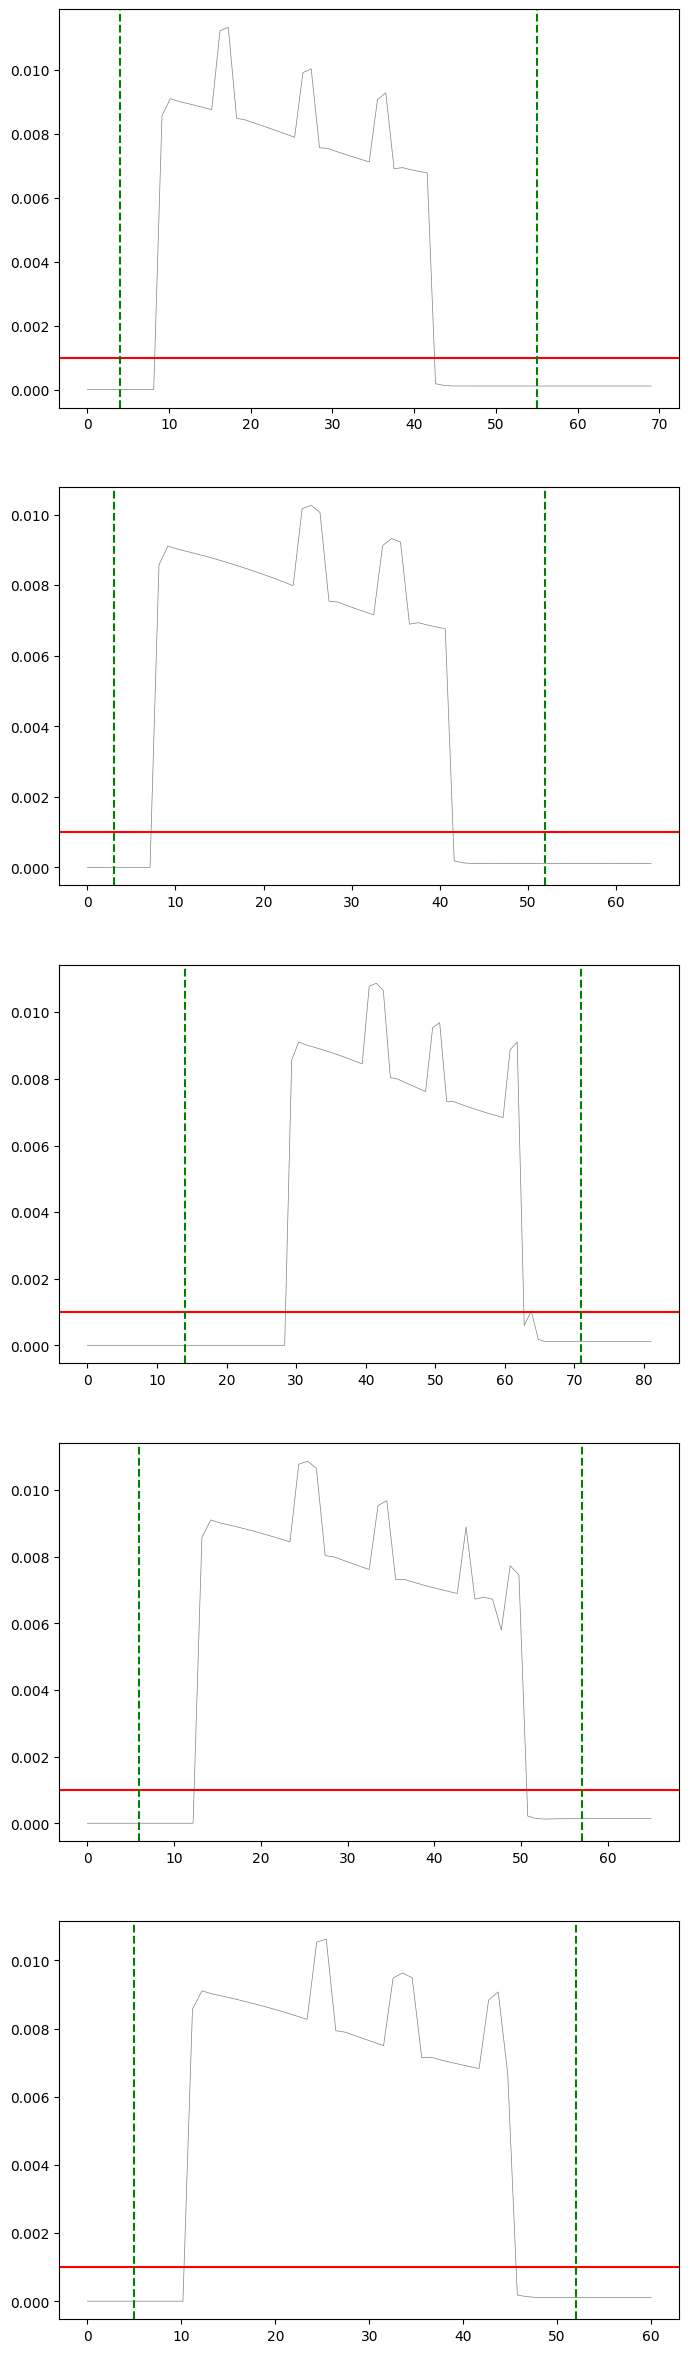

2025-08-16 03:07:35.132 | INFO     |  Creating segement of demos.
2025-08-16 03:07:35.134 | INFO     |  Subsampling to length 15 using strategy mean-length.
2025-08-16 03:07:35.134 | INFO     |  Creating segement of demos.
2025-08-16 03:07:35.136 | INFO     |  Subsampling to length 60 using strategy mean-length.
2025-08-16 03:07:35.136 | INFO     |  Creating segement of demos.
2025-08-16 03:07:35.137 | INFO     |  Subsampling to length 19 using strategy mean-length.
2025-08-16 03:07:35.138 | INFO     |  ... created 3 segments
2025-08-16 03:07:35.138 | INFO     |    Fitting candidate frame 1/10
2025-08-16 03:07:35.138 | INFO     |    Creating partial frame view of demos.
2025-08-16 03:07:35.140 | INFO     |    Changing number of components to 1


Time-based init:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-16 03:07:35.152 | INFO     |    Fitting candidate frame 2/10
2025-08-16 03:07:35.152 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-16 03:07:35.174 | INFO     |    Fitting candidate frame 3/10
2025-08-16 03:07:35.174 | INFO     |    Creating partial frame view of demos.


...

2025-08-16 03:07:36.719 | INFO     |  Changing number of components to 3


Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

((array([[9.96e+23, 9.96e+23, 6.68e+23, 3.00e+23, 9.05e+22, 1.83e+22,
          2.48e+21, 2.25e+20, 1.37e+19, 5.59e+17, 1.53e+16, 2.81e+14,
          3.45e+12, 2.85e+10, 1.58e+08, 9.96e+23, 9.96e+23, 6.68e+23,
          3.00e+23, 9.05e+22, 1.83e+22, 2.48e+21, 2.25e+20, 1.37e+19,
          5.59e+17, 1.53e+16, 2.81e+14, 3.45e+12, 2.85e+10, 1.58e+08,
          9.96e+23, 9.96e+23, 6.68e+23, 3.00e+23, 9.05e+22, 1.83e+22,
          2.48e+21, 2.25e+20, 1.37e+19, 5.59e+17, 1.53e+16, 2.81e+14,
          3.45e+12, 2.85e+10, 1.58e+08, 9.96e+23, 9.96e+23, 6.68e+23,
          3.00e+23, 9.05e+22, 1.83e+22, 2.48e+21, 2.25e+20, 1.37e+19,
          5.59e+17, 1.53e+16, 2.81e+14, 3.45e+12, 2.85e+10, 1.58e+08,
          9.96e+23, 9.96e+23, 6.68e+23, 3.00e+23, 9.05e+22, 1.83e+22,
          2.48e+21, 2.25e+20, 1.37e+19, 5.59e+17, 1.53e+16, 2.81e+14,
          3.45e+12, 2.85e+10, 1.58e+08],
         [2.07e+23, 4.88e+23, 8.17e+23, 9.69e+23, 8.17e+23, 4.88e+23,
          2.07e+23, 6.25e+22, 1.34e+22, 2.03e+21,

In [38]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.INIT,))


2025-08-16 03:07:37.033 | INFO     |  Did not specify time_based, deciding automatically.


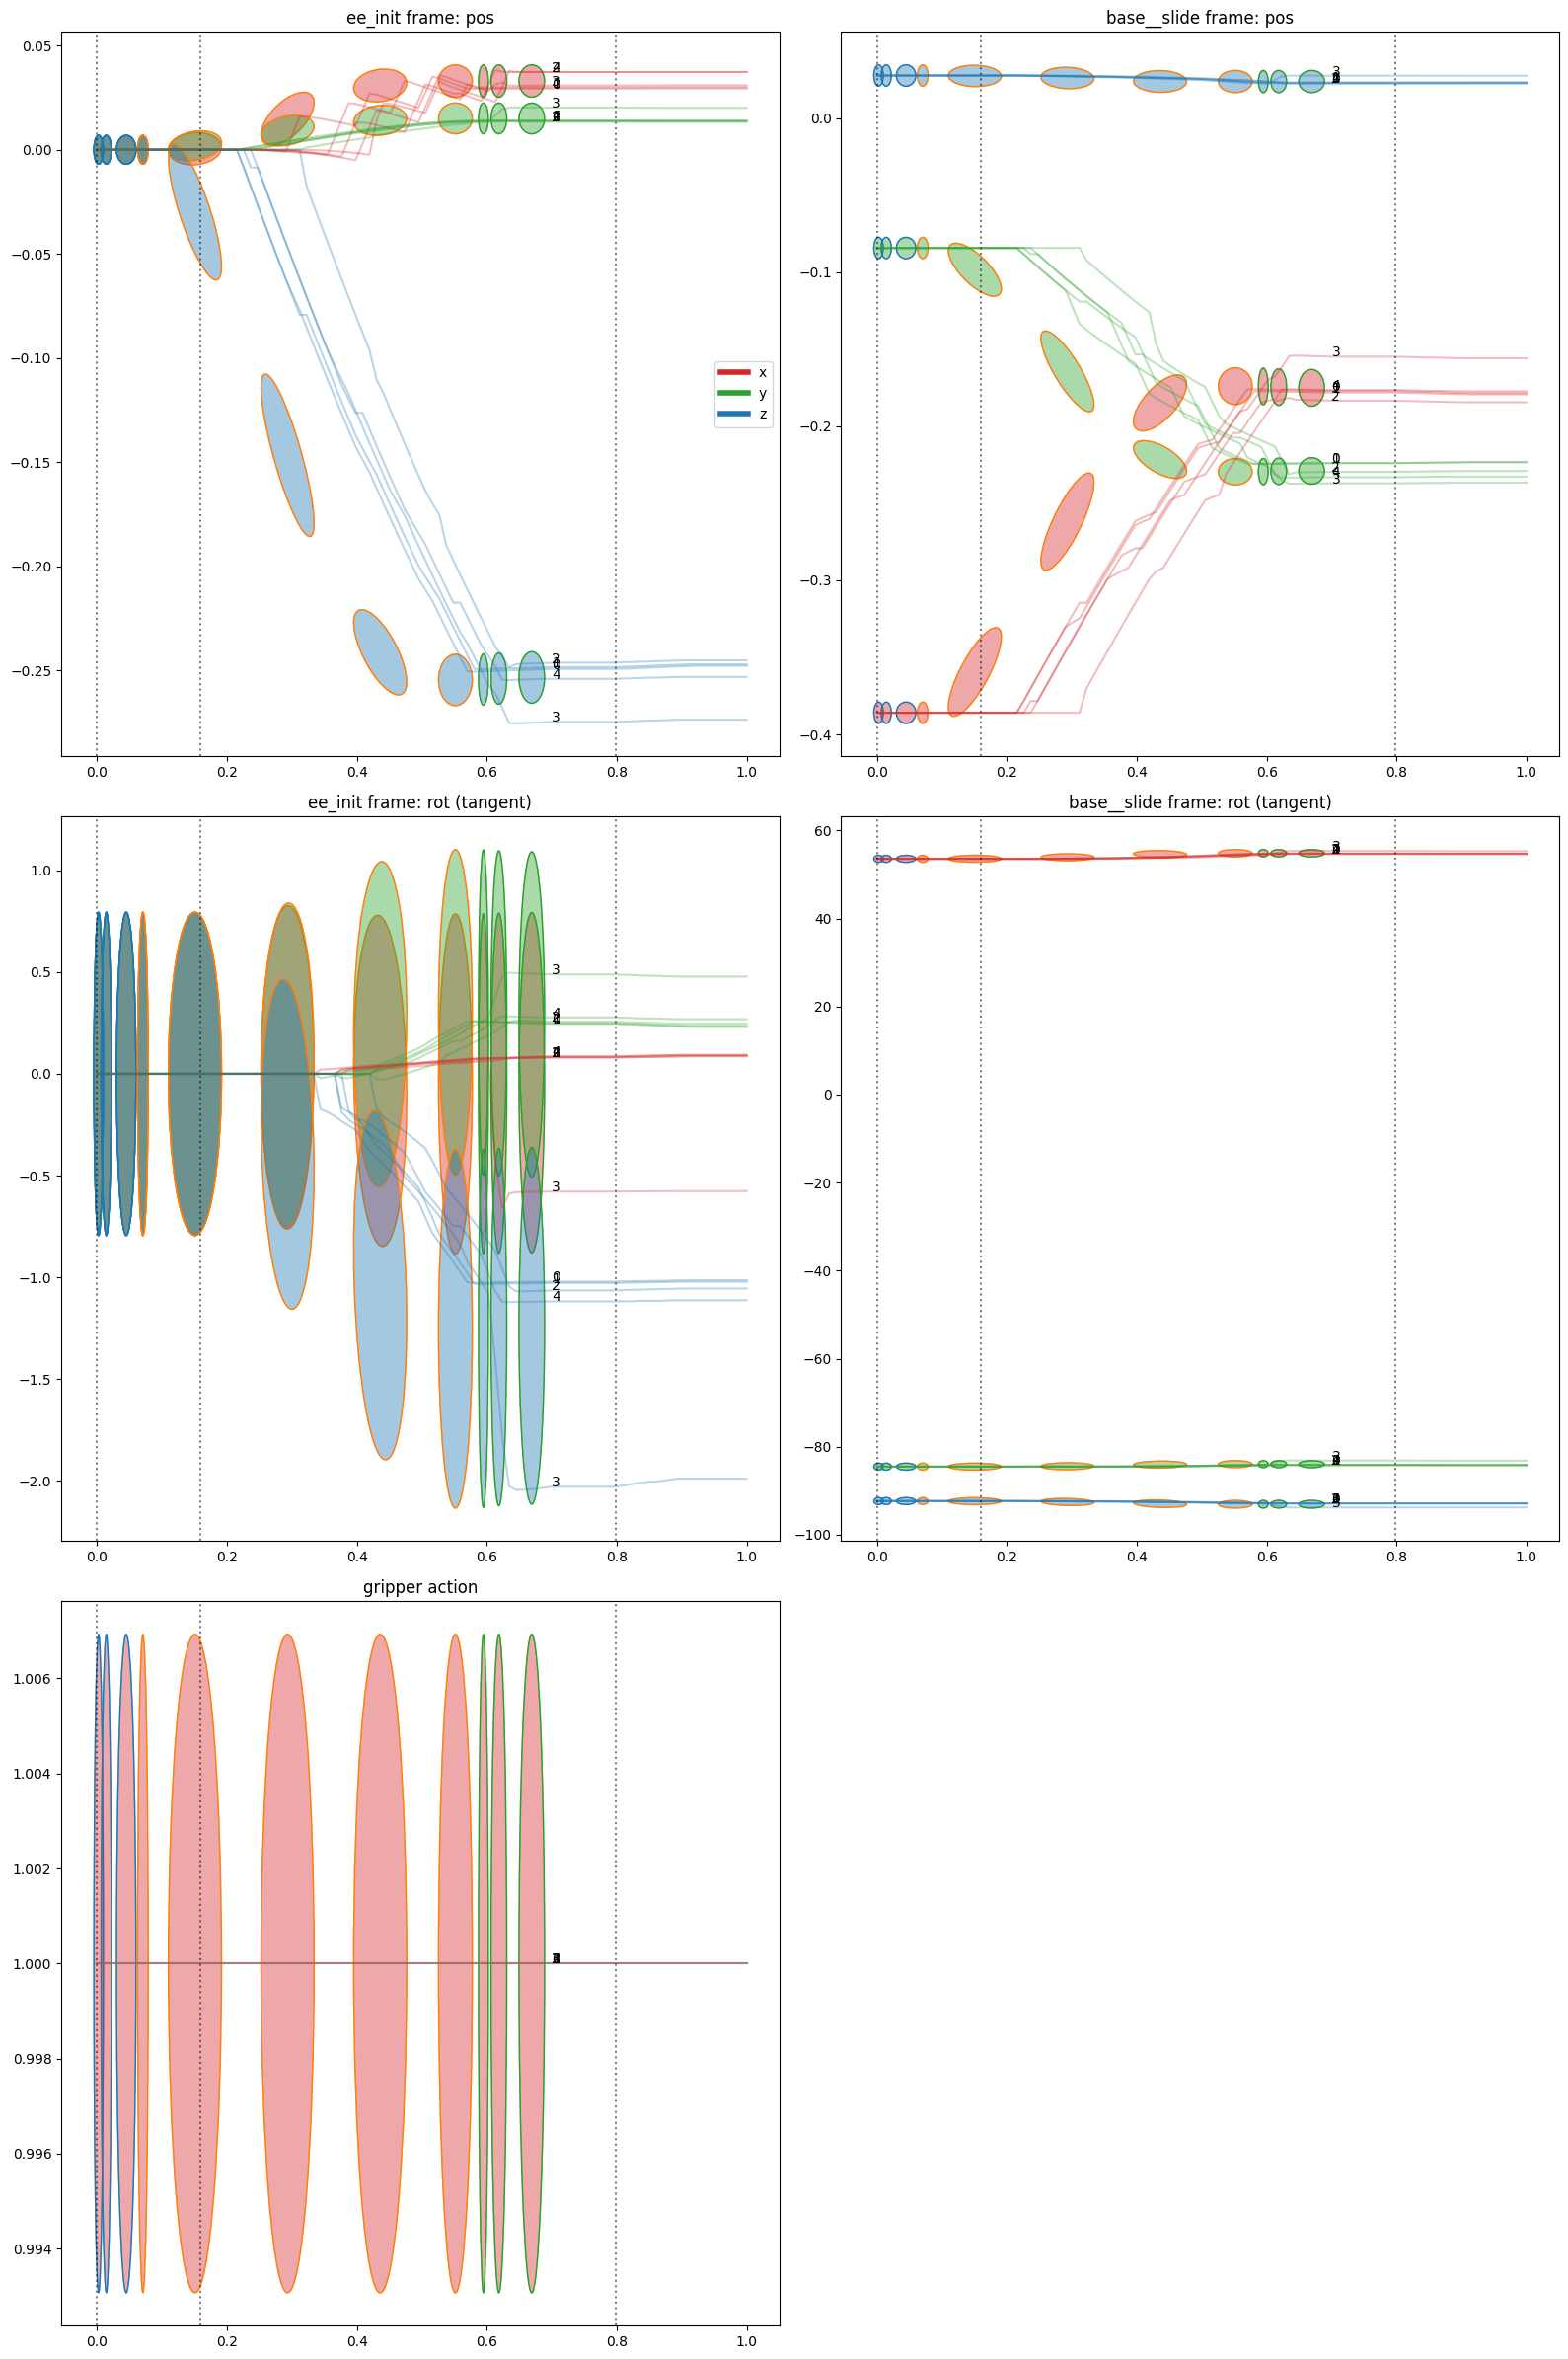

In [39]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [40]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-16 03:07:38.066 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/3 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[1.00e+00, 9.93e-01, 9.03e-01, 4.95e-01, 7.48e-02, 1.59e-03,
          3.15e-06, 4.23e-10, 2.84e-15, 7.00e-22, 4.69e-30, 6.28e-40,
          1.24e-51, 2.67e-65, 1.43e-73, 1.00e+00, 9.93e-01, 9.03e-01,
          4.95e-01, 7.48e-02, 1.59e-03, 3.15e-06, 4.23e-10, 2.84e-15,
          7.00e-22, 4.69e-30, 6.28e-40, 1.24e-51, 2.67e-65, 1.43e-73,
          1.00e+00, 9.93e-01, 9.03e-01, 4.95e-01, 7.48e-02, 1.59e-03,
          3.15e-06, 4.23e-10, 2.84e-15, 7.00e-22, 4.69e-30, 6.28e-40,
          1.24e-51, 2.67e-65, 1.43e-73, 1.00e+00, 9.93e-01, 9.03e-01,
          4.95e-01, 7.48e-02, 1.59e-03, 3.15e-06, 4.23e-10, 2.84e-15,
          7.00e-22, 4.69e-30, 6.28e-40, 1.24e-51, 2.67e-65, 1.43e-73,
          1.00e+00, 9.93e-01, 9.03e-01, 4.95e-01, 7.48e-02, 1.59e-03,
          3.15e-06, 4.23e-10, 2.84e-15, 7.00e-22, 4.69e-30, 6.28e-40,
          1.24e-51, 2.67e-65, 1.43e-73],
         [2.63e-13, 6.23e-03, 9.05e-02, 4.08e-01, 4.20e-01, 7.32e-02,
          1.58e-03, 3.15e-06, 4.23e-10, 2.84e-15,

2025-08-16 03:07:43.258 | INFO     |  Did not specify time_based, deciding automatically.


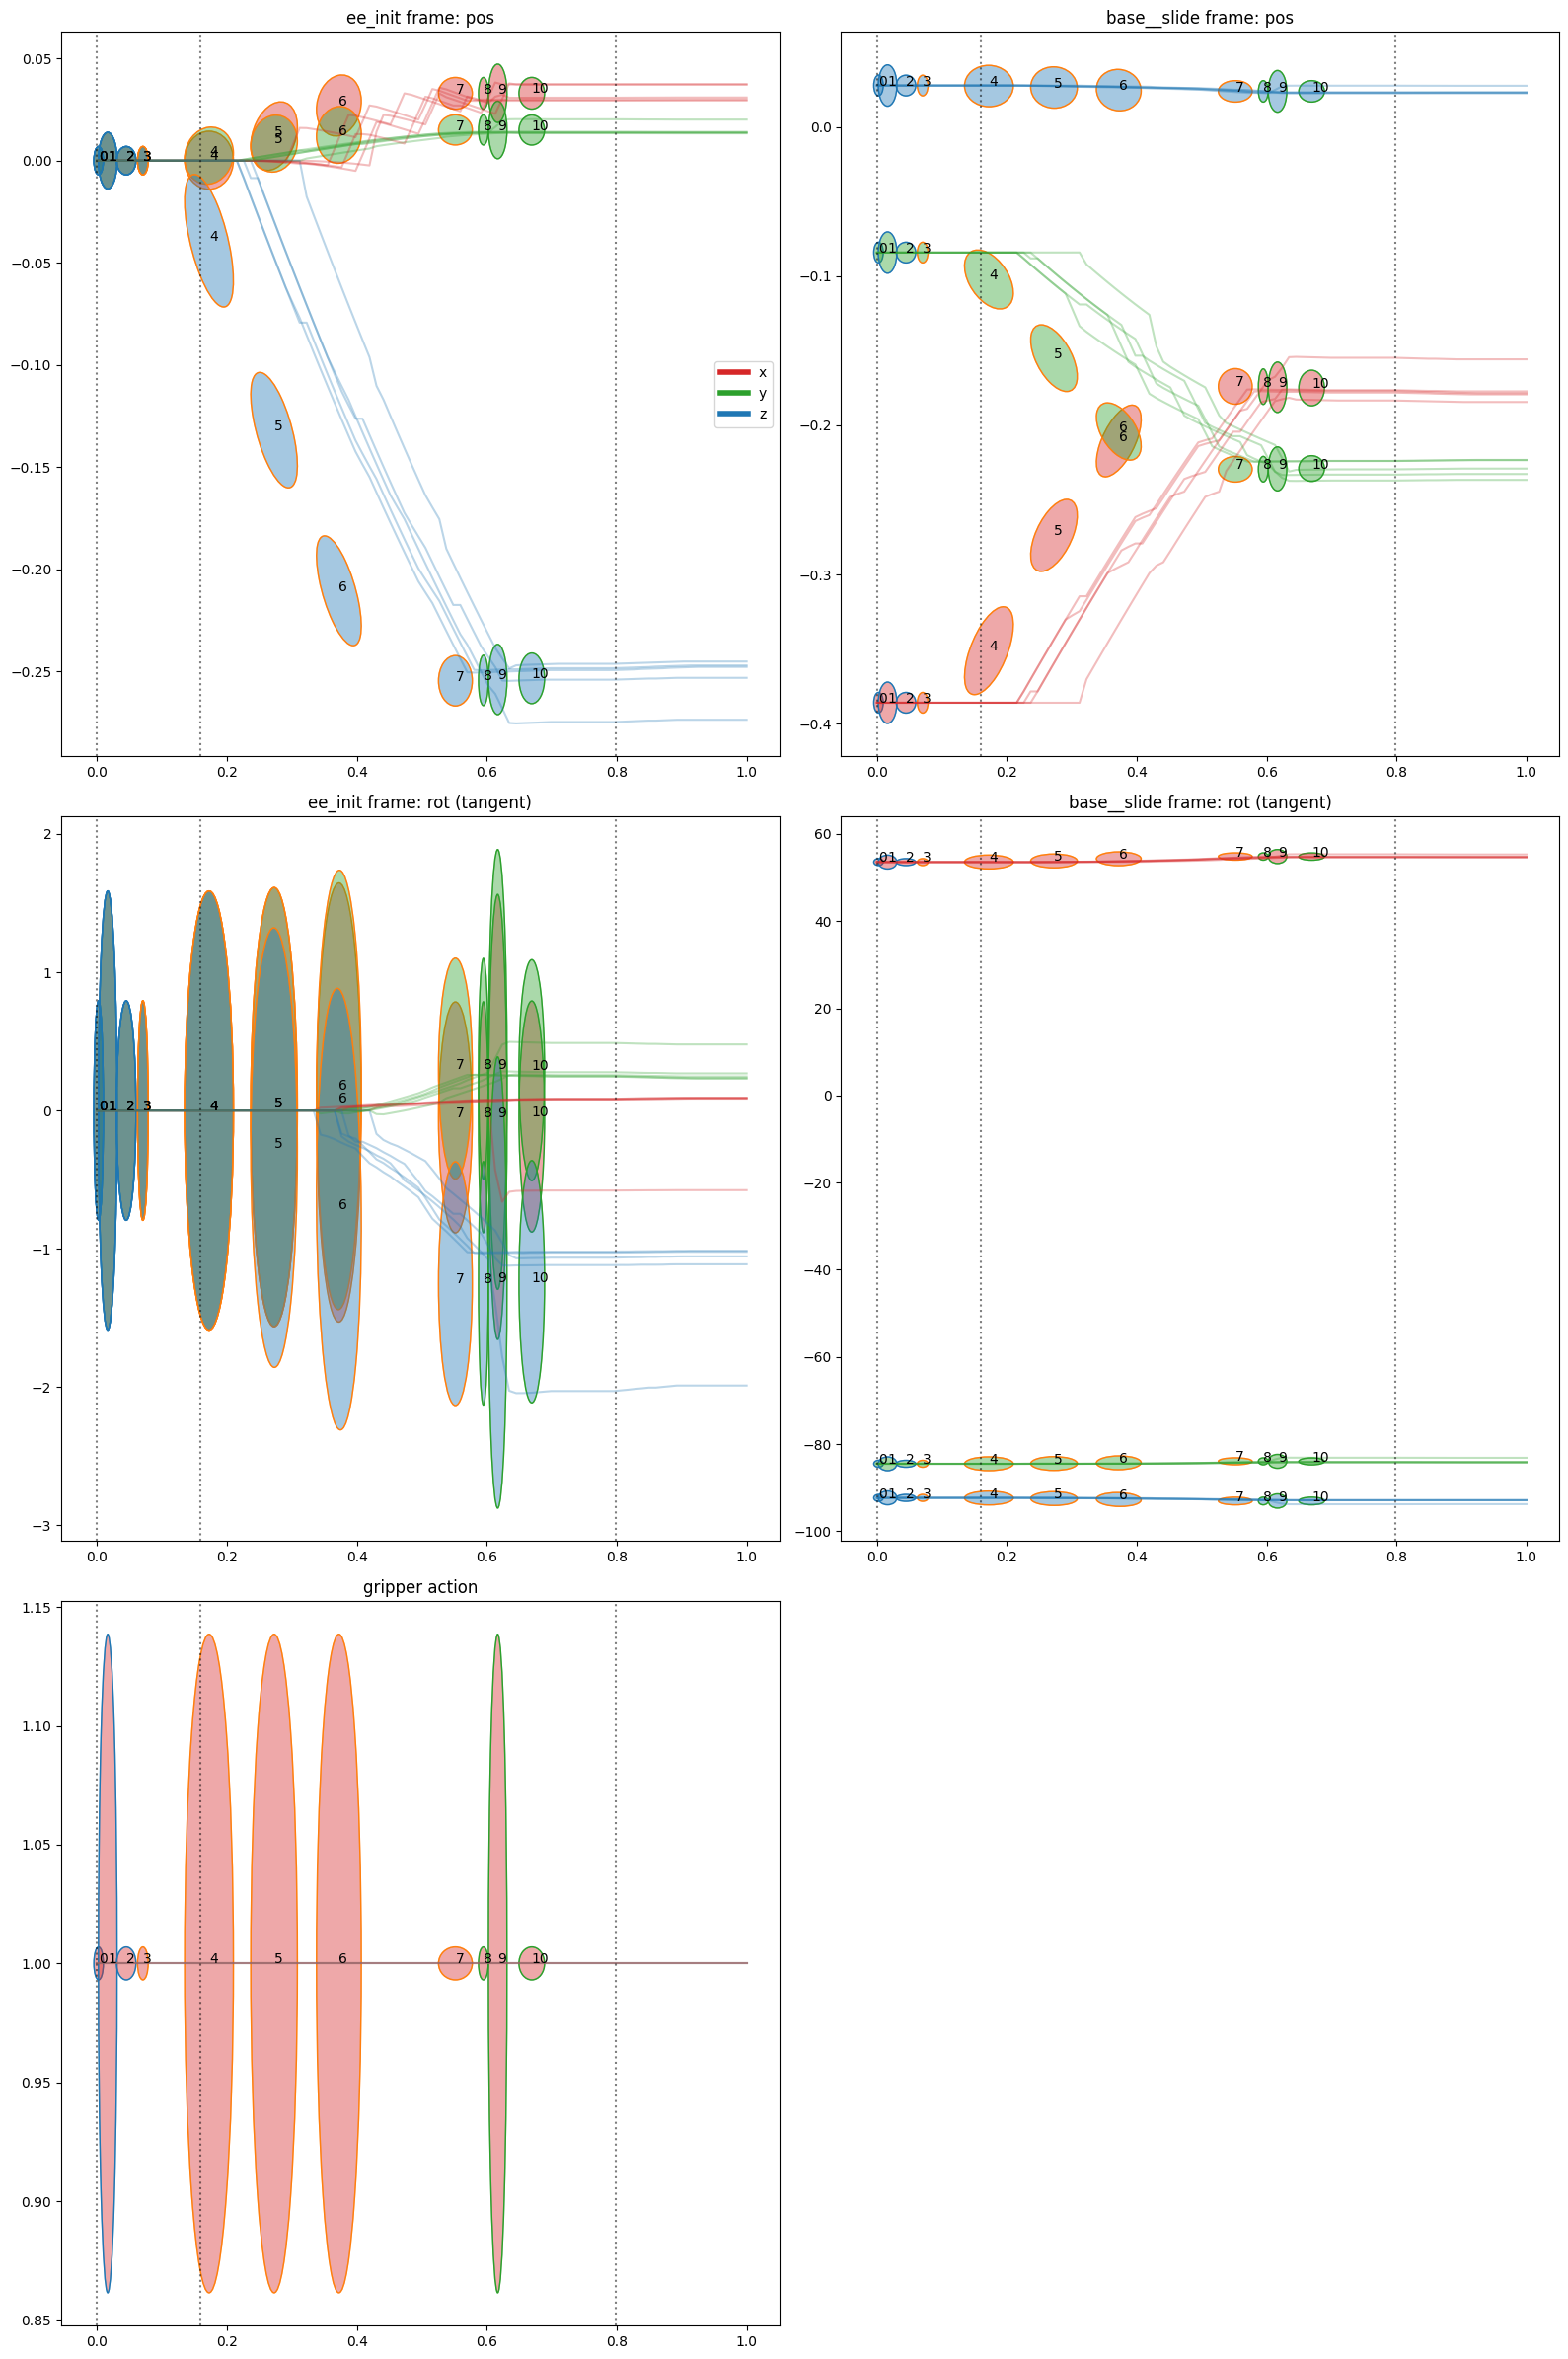

In [41]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

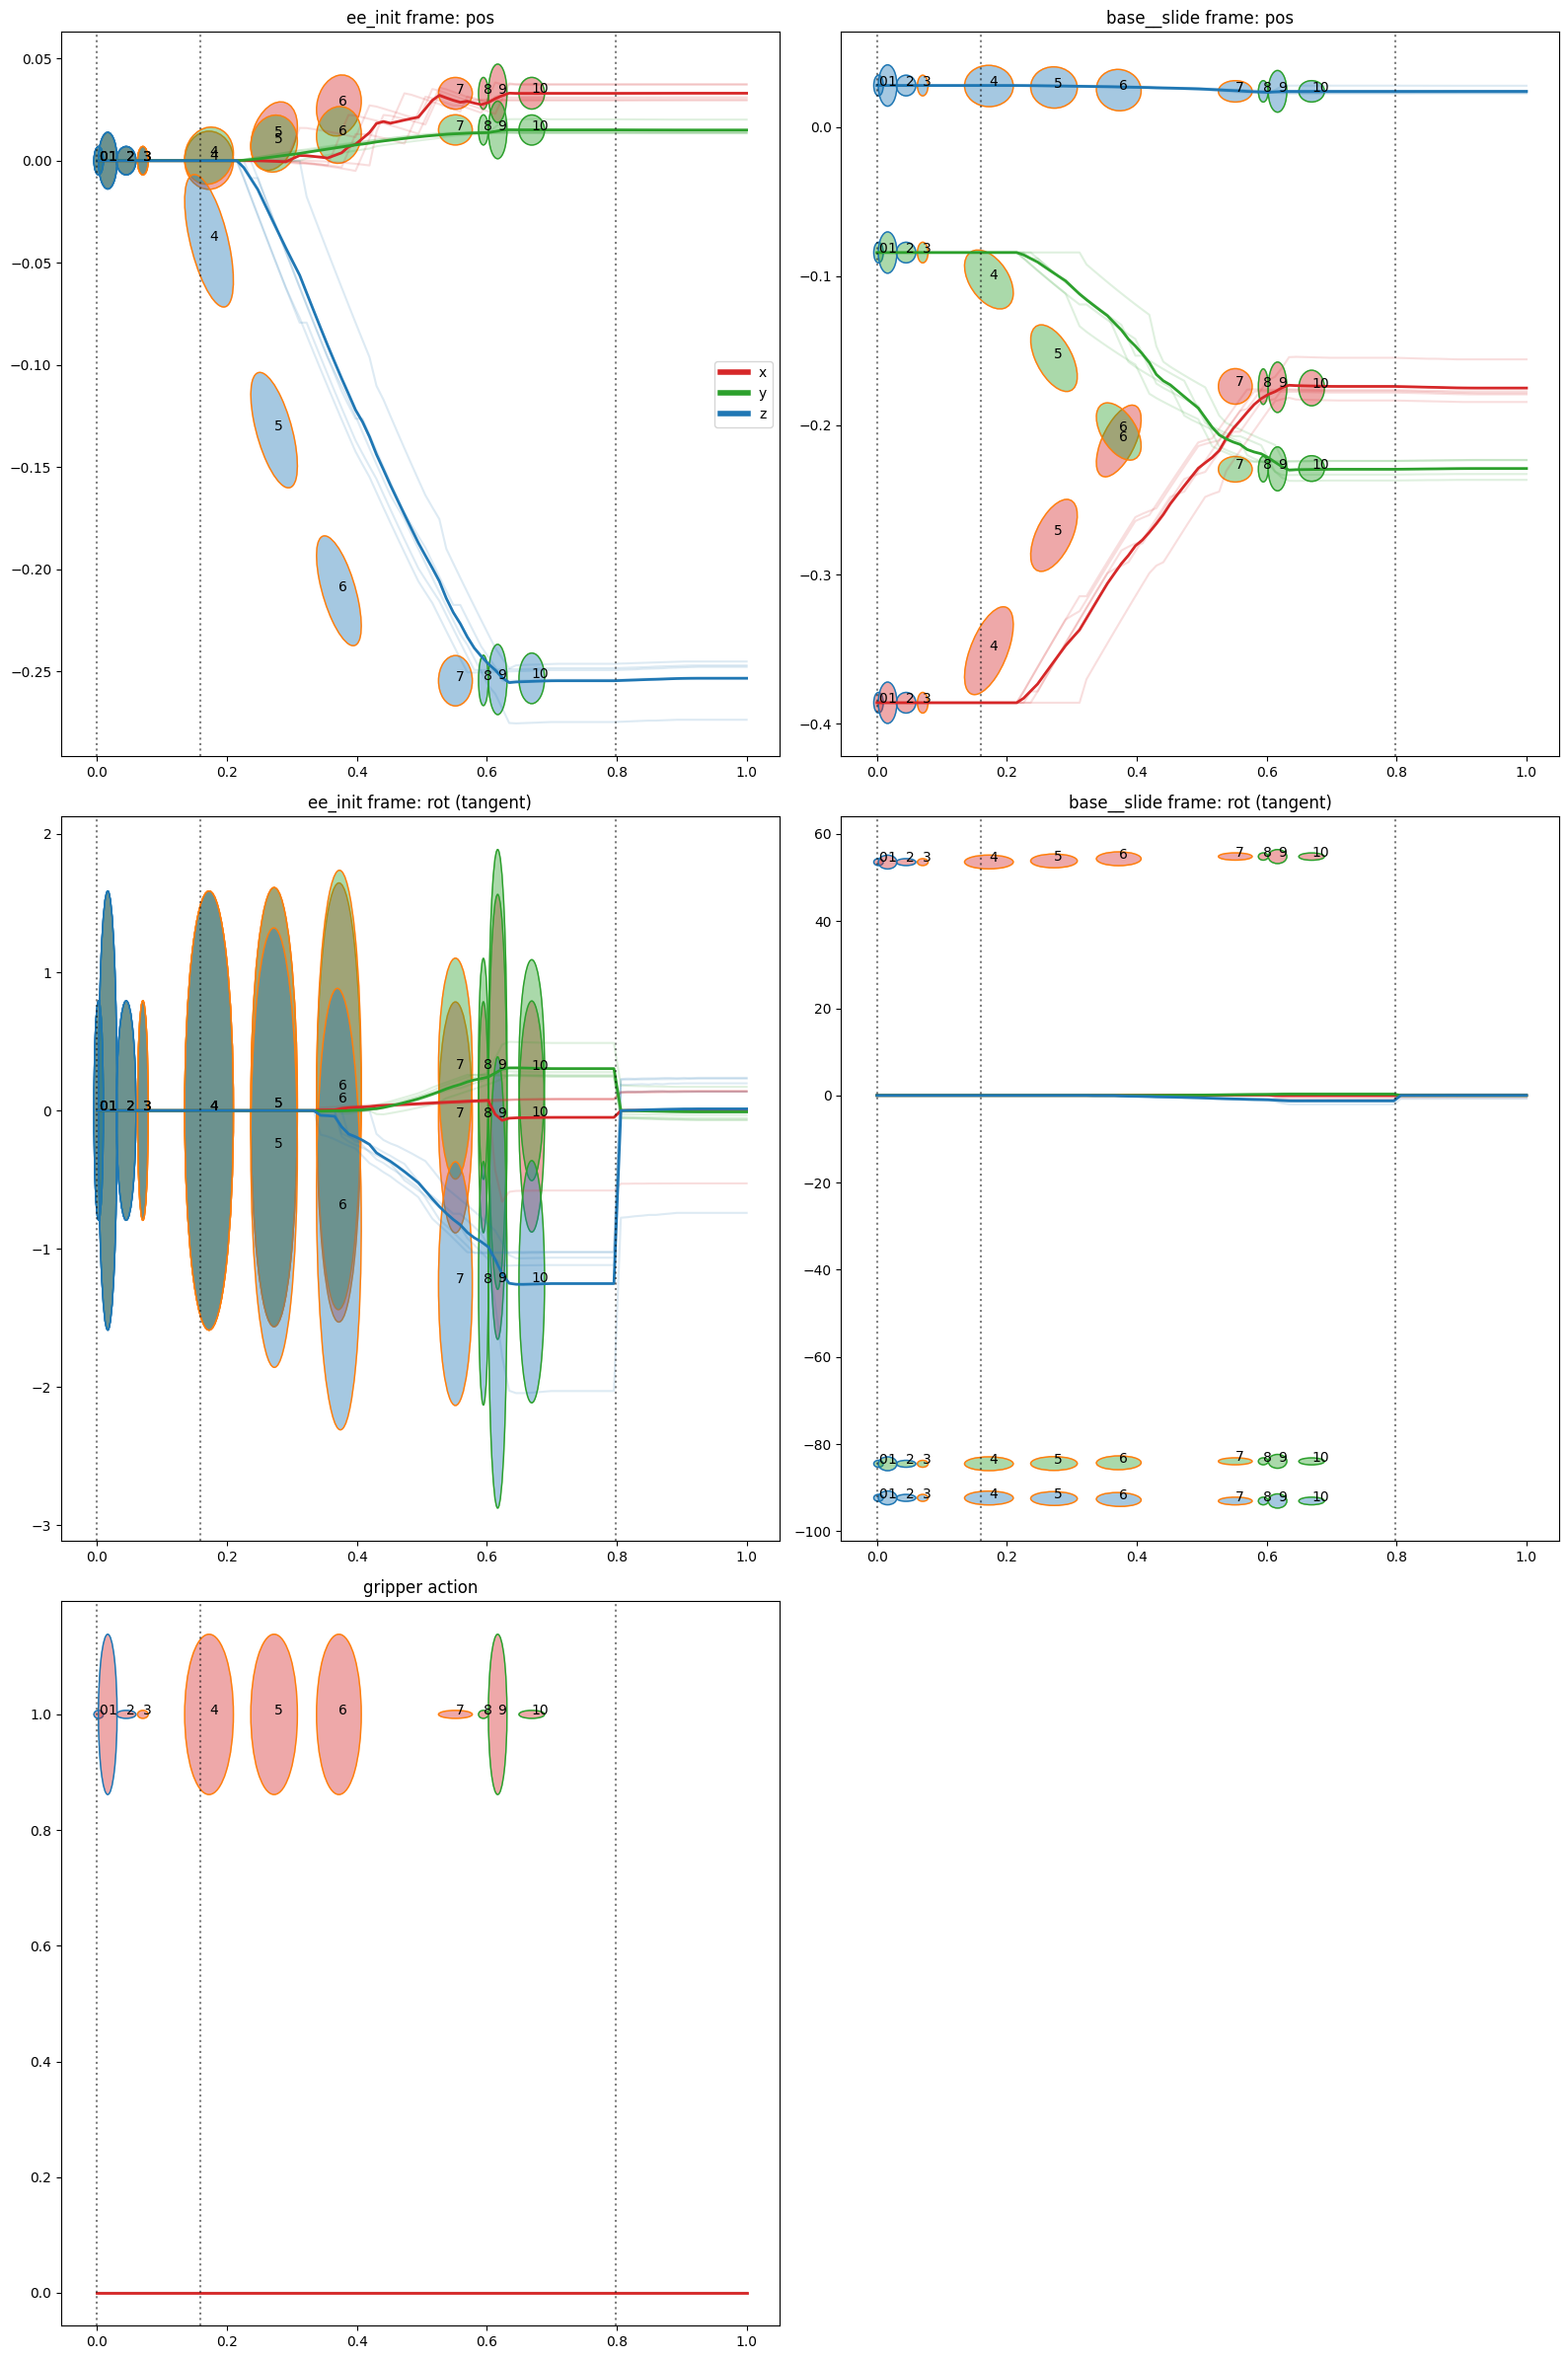

In [42]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=True, per_segment=False, gaussian_mean_only=False, plot_traj_means=True, time_based=True)

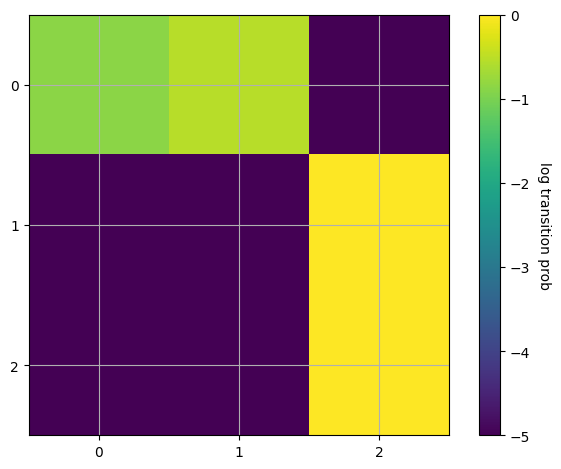

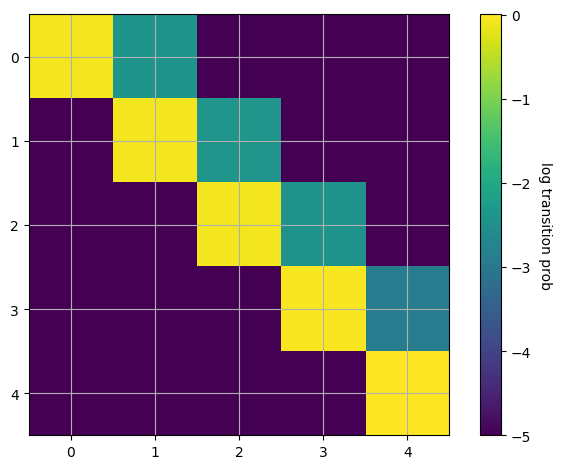

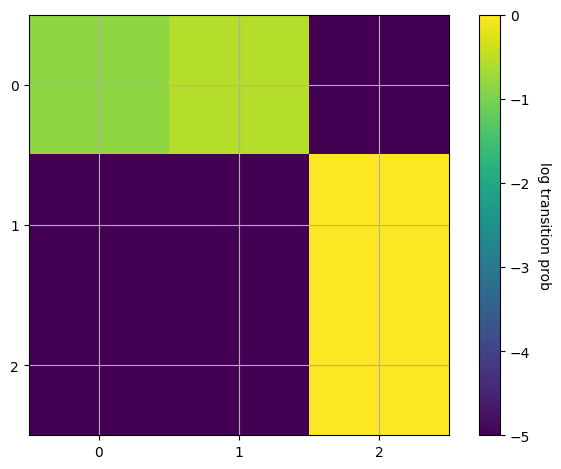

In [43]:
atpgmm.plot_hmm_transition_matrix()

In [44]:
atpgmm.to_disk(data_root / task / f'{serie}_gmm_policy-{tag}.pt')

In [45]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-16 03:08:02.985 | INFO     |  Caculated segment transition probabilities: (array([[0.01]]), array([[2.11e-09]]))
2025-08-16 03:08:02.985 | WARNING  |  At least one segment transition prob below 5%. Can lead to problems.Consider increasing the diag reg.
2025-08-16 03:08:02.985 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 03:08:03.019 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

...

2025-08-16 03:08:03.047 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 03:08:03.068 | WARNING  |  Setting init priors of later segments to zero.


GMR:   0%|          | 0/5 [00:00<?, ?it/s]

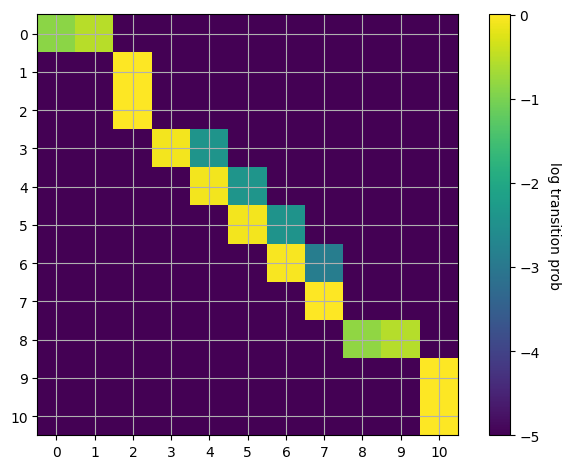

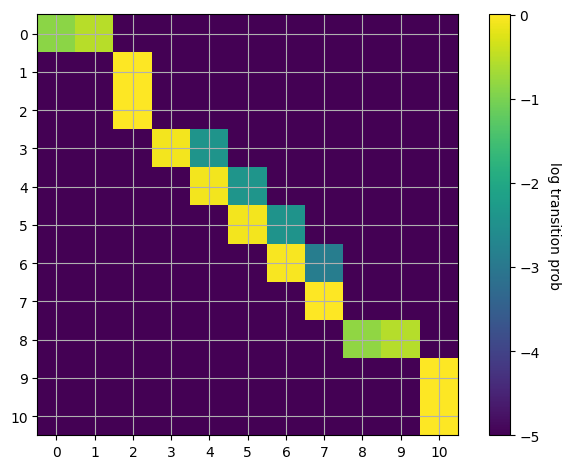

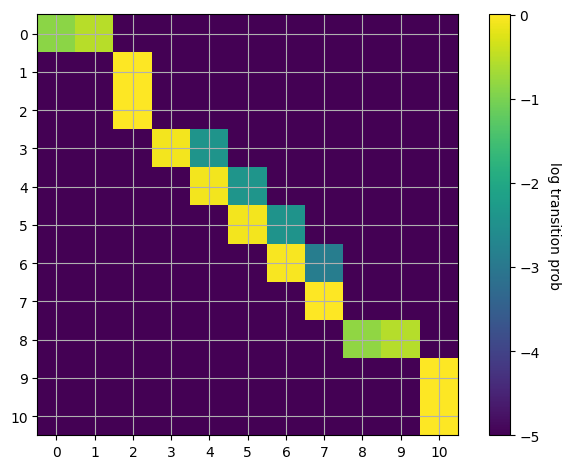

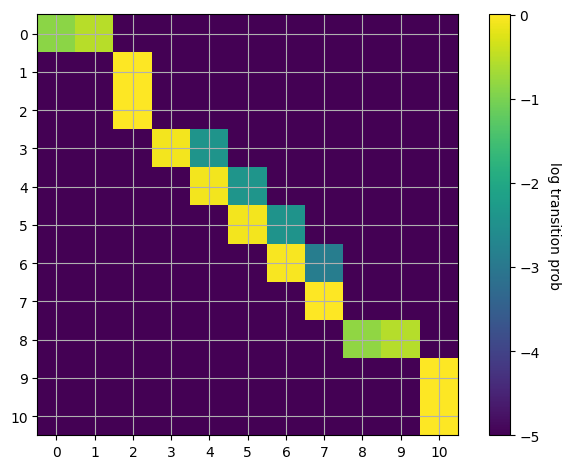

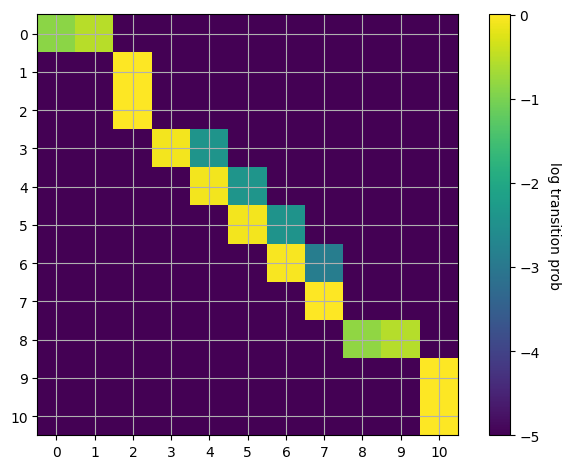

In [46]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-16 03:08:04.320 | INFO     |  Taking frame origins from demos.


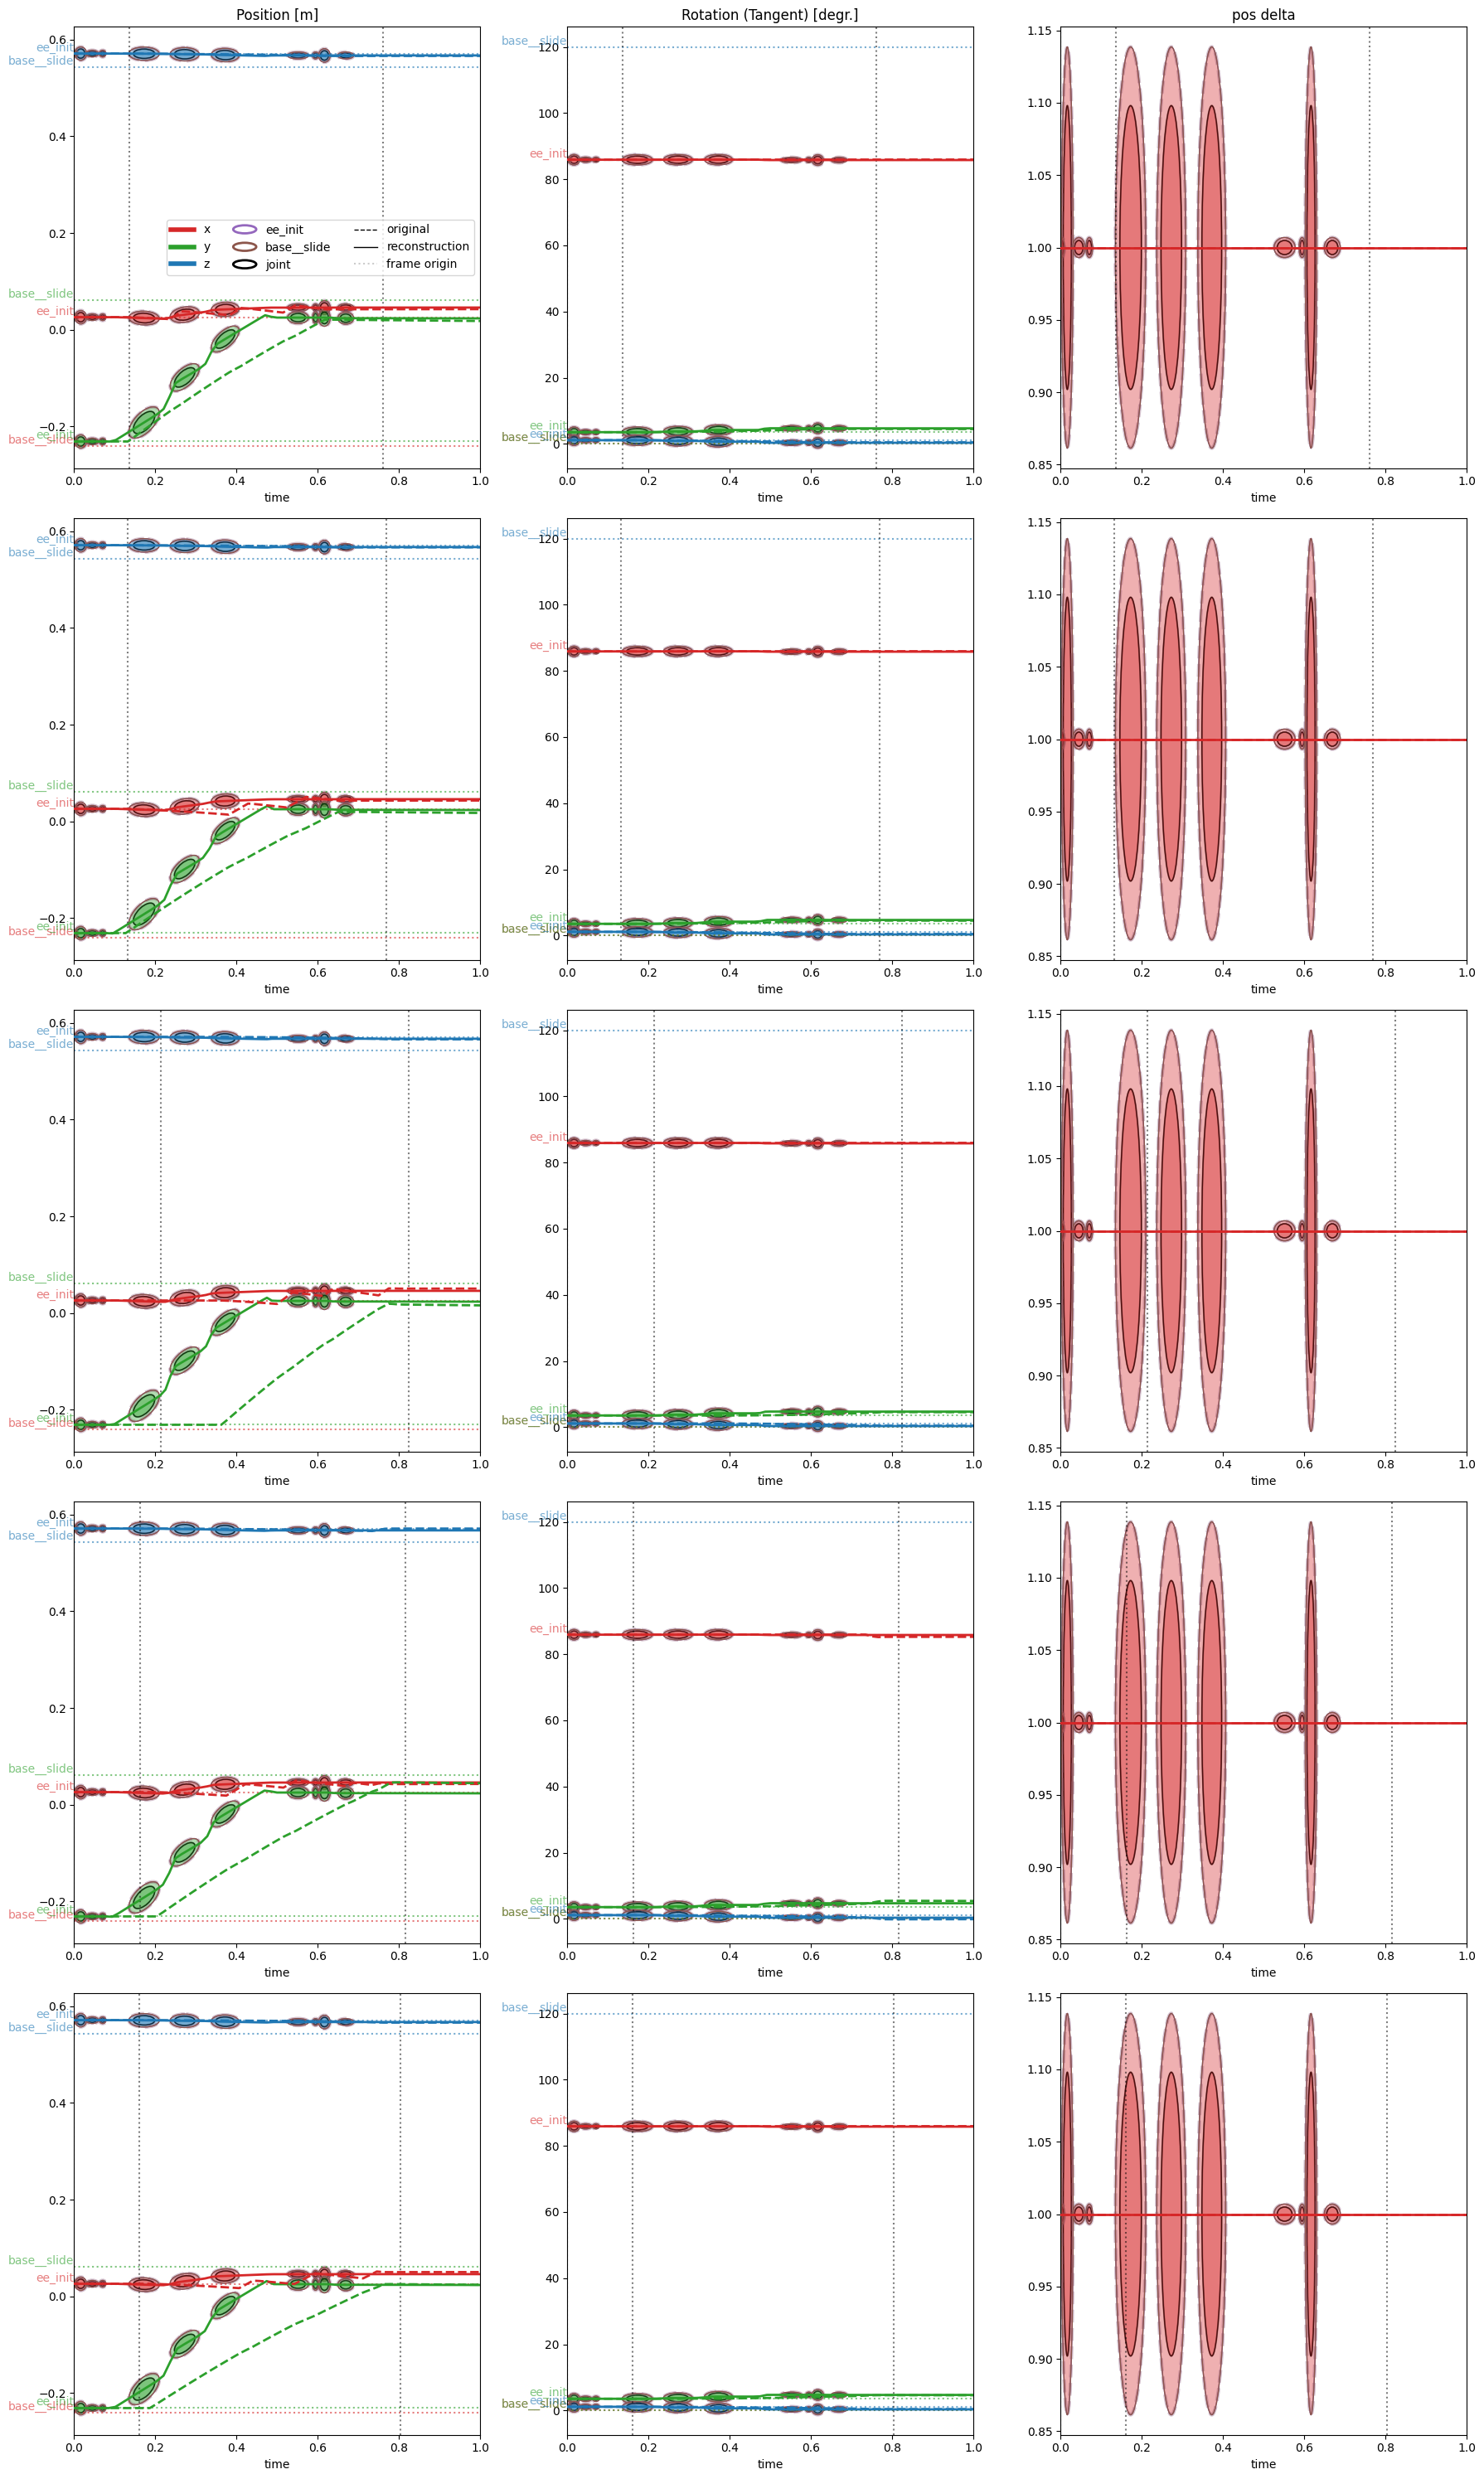

In [47]:
atpgmm.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [48]:
atpgmm.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=True,
    per_segment=False,
)

IndexError: tuple index out of range